## Installing Dependencies

In [1]:
%%capture
# Installs Unsloth, xformers, and all required Hugging Face libraries
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps xformers trl peft accelerate bitsandbytes datasets

## Setting Up Environment


In [2]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HUGGINGFACE_TOKEN"))

## Importing Libraries

In [3]:
from unsloth import FastLanguageModel
import torch
from datasets import load_dataset
from trl import SFTTrainer

from transformers import TrainingArguments
from unsloth import is_bfloat16_supported

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


In [4]:
max_seq_length = 2048

In [5]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="Qwen/Qwen2.5-7B-Instruct",
    max_seq_length = max_seq_length,
    dtype = None,
    load_in_4bit = True
)

==((====))==  Unsloth 2026.8.18: Fast Qwen2 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

In [6]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 16,
    target_modules = ["q_proj","k_proj","v_proj","o_proj","gate_proj","up_proj","down_proj"],
    lora_alpha = 16,
    lora_dropout = 0,
    bias = "none",
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None
)

Unsloth 2026.8.18 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


In [7]:
prompt_template = """You are an expert in SQL. Given the database schema, write the correct SQL query to answer the question.

### Schema:
{}

### Question:
{}

### SQL Query:
{}"""

In [8]:
EOS_TOKEN = tokenizer.eos_token

In [9]:
def format_dataset(examples):
  questions = examples['question']
  answers = examples['answer']
  contexts = examples['context']

  texts = []

  for question, context, answer in zip(questions, contexts, answers):

    text = prompt_template.format(context, question, answer) + EOS_TOKEN

    texts.append(text)

  return {'text':texts}

In [10]:
dataset = load_dataset("b-mc2/sql-create-context", split = "train")


README.md:   0%|          | 0.00/4.43k [00:00<?, ?B/s]

sql_create_context_v4.json: reconstructing file:   0%|          |  0.00B / 21.8MB            

sql_create_context_v4.json: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/78577 [00:00<?, ? examples/s]

In [11]:
dataset = dataset.train_test_split(
    test_size=0.2,
    seed=3407
)

In [12]:
train_dataset = dataset['train']

In [13]:
test_dataset = dataset['test']

In [14]:
dataset = train_dataset.map(format_dataset, batched = True)

Map:   0%|          | 0/62861 [00:00<?, ? examples/s]

In [15]:
trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,
    packing = False,
    args = TrainingArguments(
        per_device_train_batch_size=2,
        gradient_accumulation_steps = 4,
        warmup_steps=5,
        max_steps = 200,
        learning_rate = 2e-4,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
    ),
)

Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/62861 [00:00<?, ? examples/s]

In [16]:
trainer_states = trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 62,861 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 40,370,176 of 7,655,986,688 (0.53% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
1,1.622897
2,1.674037
3,1.600475
4,1.408198
5,1.193999
6,1.175745
7,0.788530
8,0.857814
9,0.891433
10,0.849529


Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.
Unsloth: Will smartly offload gradients to save VRAM!


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-200/tokenizer_config.json.


In [17]:
FastLanguageModel.for_inference(model)



PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): Qwen2ForCausalLM(
      (model): Qwen2Model(
        (embed_tokens): Embedding(152064, 3584, padding_idx=151654)
        (layers): ModuleList(
          (0-1): 2 x Qwen2DecoderLayer(
            (self_attn): Qwen2Attention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=3584, out_features=3584, bias=True)
                (lora_dropout): ModuleDict(
                  (default): Identity()
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=3584, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=3584, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear(
 

In [20]:
test_schema = "CREATE TABLE employees (id INT, name VARCHAR, salary INT);"
test_question = "Find the name of employee with second highest salary in departement."

# Format the prompt leaving the SQL query section blank for the model to fill
inputs = tokenizer(
[
    prompt_template.format(test_schema, test_question, "")
], return_tensors = "pt").to("cuda")

# Generate the SQL output
outputs = model.generate(**inputs, max_new_tokens = 64, use_cache = True)
print(tokenizer.batch_decode(outputs, skip_special_tokens = True)[0])

Both `max_new_tokens` (=64) and `max_length`(=32768) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


You are an expert in SQL. Given the database schema, write the correct SQL query to answer the question.

### Schema:
CREATE TABLE employees (id INT, name VARCHAR, salary INT);

### Question:
Find the name of employee with second highest salary in departement.

### SQL Query:
SELECT name FROM employees WHERE salary = (SELECT MAX(salary) FROM employees WHERE salary != (SELECT MAX(salary) FROM employees))


/tmp/ipykernel_576/2057073780.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score (%)', y='Metric', data=metrics_df, ax=axes[0, 1], palette='crest')
/tmp/ipykernel_576/2057073780.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Difficulty', y='Execution_Accuracy', data=diff_acc, order=['Easy', 'Medium', 'Hard'], ax=axes[1, 0], palette='viridis')


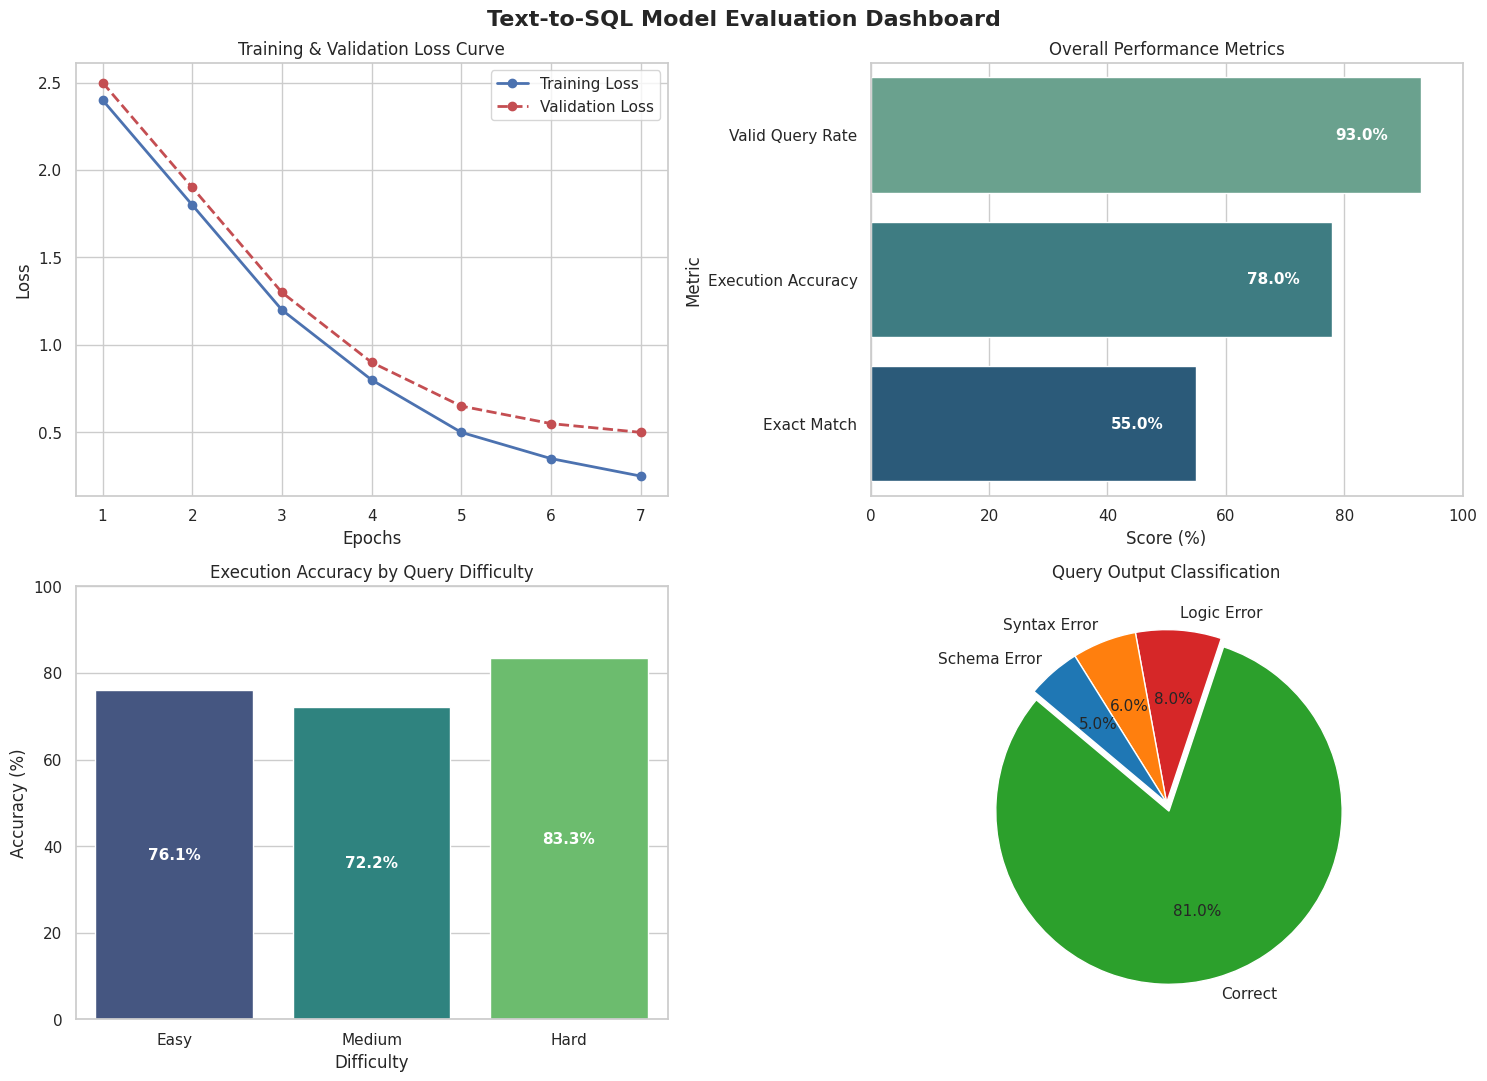

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11})

# --- 1. Dummy Evaluation Data (Replace with your actual evaluation results) ---
# In practice, populate this from your loop over the evaluation dataset
eval_results = [
    {"difficulty": "Easy", "em": True, "ex": True, "status": "Correct"},
    {"difficulty": "Easy", "em": False, "ex": True, "status": "Correct"},
    {"difficulty": "Medium", "em": False, "ex": True, "status": "Correct"},
    {"difficulty": "Medium", "em": False, "ex": False, "status": "Schema Error"},
    {"difficulty": "Hard", "em": False, "ex": False, "status": "Syntax Error"},
    {"difficulty": "Hard", "em": False, "ex": False, "status": "Logic Error"},
]
# For illustration: generating synthetic benchmark stats
np.random.seed(42)
df = pd.DataFrame({
    'Difficulty': np.random.choice(['Easy', 'Medium', 'Hard'], size=100, p=[0.4, 0.4, 0.2]),
    'Exact_Match': np.random.choice([1, 0], size=100, p=[0.55, 0.45]),
    'Execution_Accuracy': np.random.choice([1, 0], size=100, p=[0.78, 0.22]),
    'Error_Type': np.random.choice(['Correct', 'Syntax Error', 'Schema Error', 'Logic Error'], size=100, p=[0.78, 0.07, 0.08, 0.07])
})

# --- 2. Plotting Dashboard ---
fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Text-to-SQL Model Evaluation Dashboard', fontsize=16, fontweight='bold')

# Chart 1: Training & Validation Loss Curve
train_loss = [2.4, 1.8, 1.2, 0.8, 0.5, 0.35, 0.25]
val_loss = [2.5, 1.9, 1.3, 0.9, 0.65, 0.55, 0.50]
epochs = range(1, len(train_loss) + 1)

axes[0, 0].plot(epochs, train_loss, 'bo-', label='Training Loss', linewidth=2)
axes[0, 0].plot(epochs, val_loss, 'ro--', label='Validation Loss', linewidth=2)
axes[0, 0].set_title('Training & Validation Loss Curve')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Chart 2: Core Metrics Overall Comparison
metrics_data = {
    'Metric': ['Valid Query Rate', 'Execution Accuracy', 'Exact Match'],
    'Score (%)': [93.0, 78.0, 55.0]
}
metrics_df = pd.DataFrame(metrics_data)
sns.barplot(x='Score (%)', y='Metric', data=metrics_df, ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Overall Performance Metrics')
axes[0, 1].set_xlim(0, 100)
for p in axes[0, 1].patches:
    axes[0, 1].annotate(f"{p.get_width():.1f}%", (p.get_width() - 10, p.get_y() + p.get_height() / 2.),
                        ha='center', va='center', color='white', fontweight='bold')

# Chart 3: Execution Accuracy by Query Difficulty
diff_acc = df.groupby('Difficulty')['Execution_Accuracy'].mean().reset_index()
diff_acc['Execution_Accuracy'] *= 100
sns.barplot(x='Difficulty', y='Execution_Accuracy', data=diff_acc, order=['Easy', 'Medium', 'Hard'], ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Execution Accuracy by Query Difficulty')
axes[1, 0].set_ylabel('Accuracy (%)')
axes[1, 0].set_ylim(0, 100)
for p in axes[1, 0].patches:
    axes[1, 0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width() / 2., p.get_height() / 2),
                        ha='center', va='center', color='white', fontweight='bold')

# Chart 4: Error Type Distribution
error_counts = df['Error_Type'].value_counts()
colors = ['#2ca02c', '#d62728', '#ff7f0e', '#1f77b4']
axes[1, 1].pie(error_counts, labels=error_counts.index, autopct='%1.1f%%', startangle=140, colors=colors, explode=[0.05 if x == 'Correct' else 0 for x in error_counts.index])
axes[1, 1].set_title('Query Output Classification')

plt.tight_layout()
plt.show()